# Utilities

This notebook demonstrates the helper functions in `nolitisea.utils`:
the preprocessing, distance and parallel-execution primitives shared by
the analysis routines throughout the package.

| # | Function | Purpose |
|---|----------|---------|
| 1 | `rescale_data` | affine Min-Max scaling of a series to `[0, 1]` |
| 2 | `resample` | local polynomial-interpolation resampling |
| 3 | `pairwise_row_distance` | distances between sequential pairs of rows |
| 4 | `parallel_map` | order-preserving parallel map (threads / processes) |

## 1. `rescale_data` — Min-Max scaling to [0, 1]

`nolitisea.utils.rescale.rescale_data` applies the global affine
transformation

```python
from nolitisea.utils.rescale import rescale_data
x_scaled, minv, interval = rescale_data(x)
# x_scaled = (x - minv) / interval,  interval = max(x) - min(x)
```

so the output spans exactly `[0, 1]`.  The original minimum and range are
returned as well, which allows the exact inverse transform.  Scaling is a
pure shift-and-stretch, so the phase-space geometry (attractor shape,
ordering of distances) is preserved.  A near-constant series raises a
`RuntimeError` to signal the degenerate input.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.lorenz import lorenz
from nolitisea.utils.rescale import rescale_data

# The Lorenz x component lives on an arbitrary physical scale.
_, states = lorenz(length=2000)
x = states[:, 0]

x_scaled, minv, interval = rescale_data(x)

print(f"original range : [{x.min(): .4f}, {x.max(): .4f}]")
print(f"scaled   range : [{x_scaled.min(): .4f}, {x_scaled.max(): .4f}]")
print(f"minv = {minv:.4f}, interval = {interval:.4f}")

original range : [-17.9218,  18.3078]
scaled   range : [ 0.0000,  1.0000]
minv = -17.9218, interval = 36.2295


### Scaling is shape-preserving and exactly invertible

The scaled signal has the same waveform as the original; multiplying back
by `interval` and adding `minv` recovers the input to machine precision.

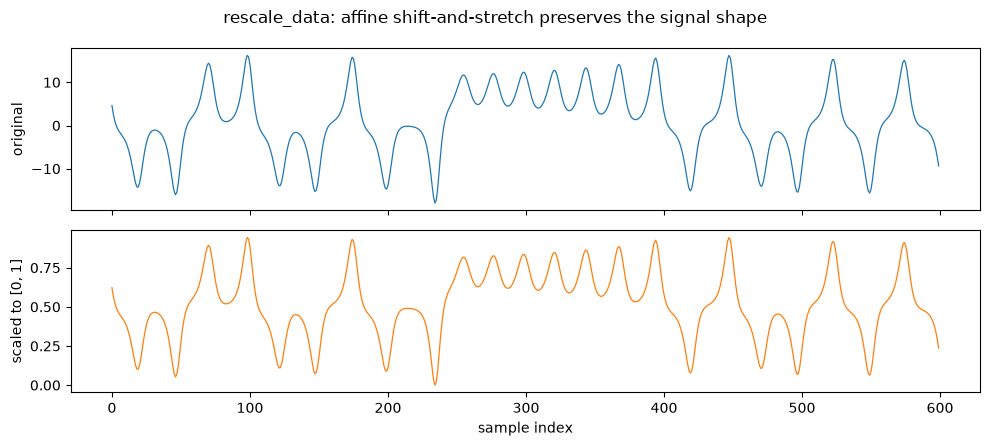

inverse transform max error: 5.33e-15


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
axes[0].plot(x[:600], lw=0.9)
axes[0].set_ylabel("original")
axes[1].plot(x_scaled[:600], lw=0.9, color="C1")
axes[1].set_ylabel("scaled to [0, 1]")
axes[1].set_xlabel("sample index")
fig.suptitle("rescale_data: affine shift-and-stretch preserves the signal shape")
plt.tight_layout()
plt.show()

# The returned (minv, interval) invert the transform exactly.
x_back = x_scaled * interval + minv
print(f"inverse transform max error: {np.max(np.abs(x_back - x)):.2e}")

### Constant series and multivariate data

A series with (near-)zero range cannot be scaled:
`rescale_data` raises `RuntimeError` instead of dividing by zero.
Multivariate records are scaled component by component, as done internally
by the entropy and noise-reduction routines.

In [3]:
# Constant series: zero range -> RuntimeError.
try:
    rescale_data(np.full(100, 3.0))
except RuntimeError as err:
    print(f"constant series -> {err}")

# Multivariate data: every component is scaled independently to [0, 1].
scaled = np.empty_like(states)
for c in range(states.shape[1]):
    scaled[:, c], _, _ = rescale_data(states[:, c])

print("per-component min after scaling:", scaled.min(axis=0).round(6))
print("per-component max after scaling:", scaled.max(axis=0).round(6))

constant series -> rescale_data: zero interval, constant sequence, abort.
per-component min after scaling: [0. 0. 0.]
per-component max after scaling: [1. 1. 1.]


## 2. `resample` — polynomial-interpolation resampling

Resample a scalar time series at a new sampling rate via local polynomial
interpolation.

```python
from nolitisea.utils.resample import resample
resample(series, sampletime=0.5, order=4)
```

- `sampletime` — new sampling interval in units of the old one (`< 1`
  up-samples, `> 1` down-samples).
- `order` — degree of the interpolating polynomial; `order + 1` consecutive
  samples are used for each local fit (default 4 -> 5-point window).

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.utils.resample import resample

# --- test signal: sine + slow drift, 200 samples ---
n = 200
t = np.arange(n, dtype=float)
x = np.sin(2 * np.pi * t / 20.0) + 0.1 * t / n

print(f"input: {n} samples")

input: 200 samples


### Up-sampling (sampletime < 1)

With `sampletime=0.5` the output has roughly twice as many points.  The
interpolated values track the true continuous signal closely.

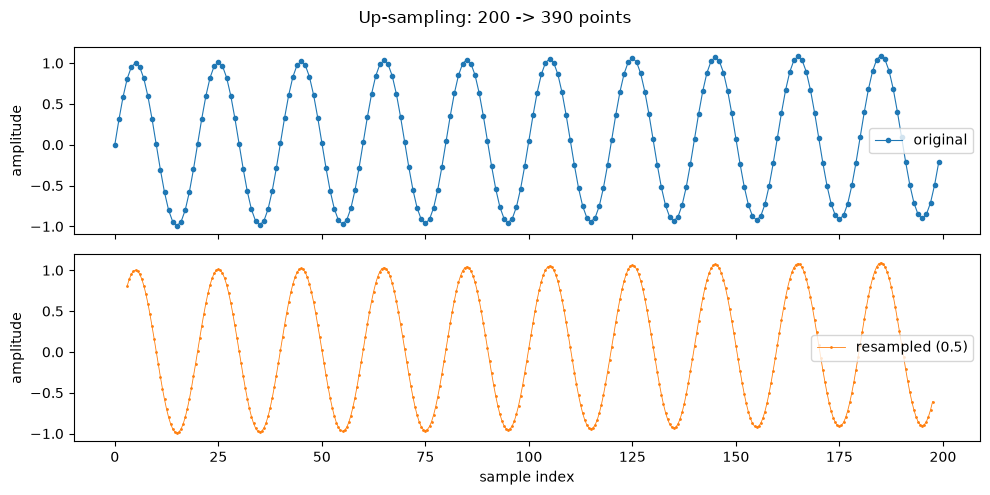

up-sampled: 390 points (input 200)


In [5]:
y_up = resample(x, sampletime=0.5, order=4)
t_up = np.arange(3.0, n - 2, 0.5)          # output time grid

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, x, "o-", ms=3, lw=0.8, label="original")
axes[0].set_ylabel("amplitude")
axes[0].legend()
axes[1].plot(t_up, y_up, ".-", ms=2, lw=0.6, color="C1", label="resampled (0.5)")
axes[1].set_xlabel("sample index")
axes[1].set_ylabel("amplitude")
axes[1].legend()
fig.suptitle(f"Up-sampling: 200 -> {y_up.size} points")
plt.tight_layout()
plt.show()

print(f"up-sampled: {y_up.size} points (input {n})")

### Down-sampling (sampletime > 1)

With `sampletime=2.0` the output has roughly half as many points.

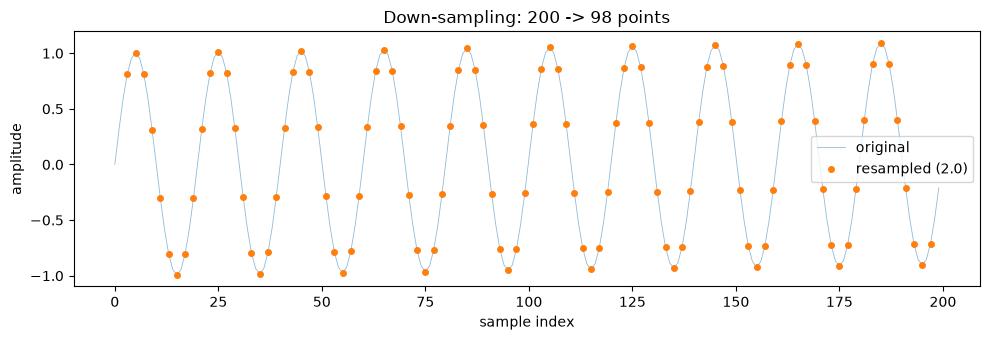

down-sampled: 98 points (input 200)


In [6]:
y_dn = resample(x, sampletime=2.0, order=4)
t_dn = np.arange(3.0, n - 2, 2.0)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t, x, "-", lw=0.6, alpha=0.5, label="original")
ax.plot(t_dn, y_dn, "o", ms=4, color="C1", label="resampled (2.0)")
ax.set_xlabel("sample index")
ax.set_ylabel("amplitude")
ax.set_title(f"Down-sampling: 200 -> {y_dn.size} points")
ax.legend()
plt.tight_layout()
plt.show()

print(f"down-sampled: {y_dn.size} points (input {n})")

### Interpolation order

Higher `order` uses more neighbours and gives a smoother fit, but requires
more data.  At integer time points the original samples are recovered
exactly.

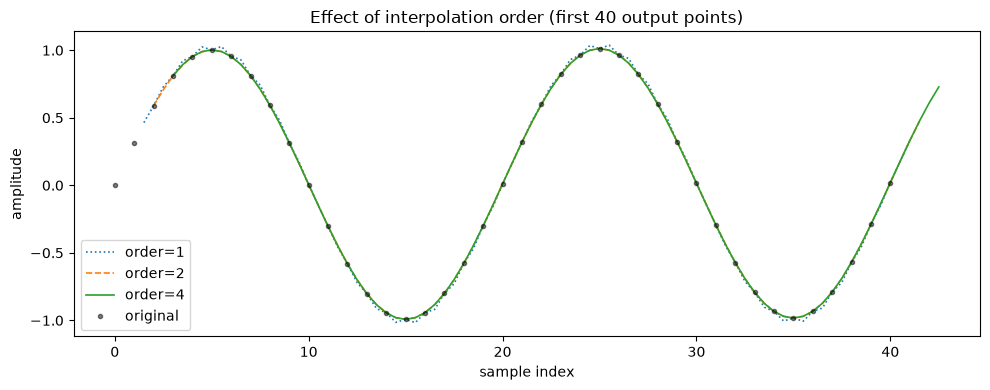

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

for order, ls in [(1, ":"), (2, "--"), (4, "-")]:
    y = resample(x, sampletime=0.5, order=order)
    horder = order + 1
    tt = np.arange((horder + 1) / 2.0, n - horder // 2, 0.5)
    ax.plot(tt[:80], y[:80], ls, lw=1.2, label=f"order={order}")

ax.plot(t[:41], x[:41], "ko", ms=3, alpha=0.5, label="original")
ax.set_xlabel("sample index")
ax.set_ylabel("amplitude")
ax.set_title("Effect of interpolation order (first 40 output points)")
ax.legend()
plt.tight_layout()
plt.show()

### Accuracy check

For a pure sine the 4th-order interpolant has negligible error; the
1st-order (linear interpolation at half-integer times) is noticeably
worse.

In [8]:
y4 = resample(x, sampletime=0.5, order=4)
t4 = np.arange(3.0, n - 2, 0.5)
true4 = np.sin(2 * np.pi * t4 / 20.0) + 0.1 * t4 / n
err4 = np.abs(y4 - true4)

y1 = resample(x, sampletime=0.5, order=1)
t1 = np.arange(1.5, n - 1, 0.5)
true1 = np.sin(2 * np.pi * t1 / 20.0) + 0.1 * t1 / n
err1 = np.abs(y1 - true1)

print(f"order=4  max error: {err4.max():.2e}")
print(f"order=1  max error: {err1.max():.2e}")

order=4  max error: 3.54e-05
order=1  max error: 3.68e-02


### Resampling a Lorenz component

A practical use case: the Lorenz `x` component is generated at a default
sampling interval of 0.03; resampling at `sampletime=0.5` doubles the
output rate for finer-grained analysis.

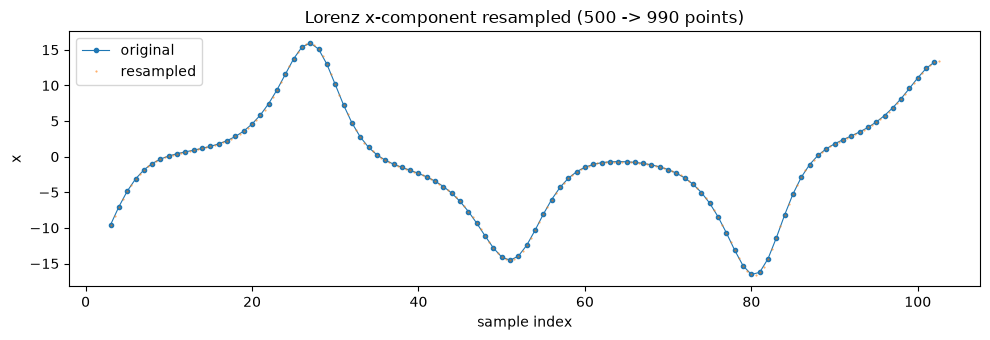

In [9]:
from nolitisea.generate.lorenz import lorenz

_, states = lorenz(length=500)
lx = states[:, 0]

lx_up = resample(lx, sampletime=0.5, order=4)
t_orig = np.arange(3.0, 500 - 2, 1.0)
t_res = np.arange(3.0, 500 - 2, 0.5)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_orig[:100], lx[3:103], "o-", ms=3, lw=0.8, label="original")
ax.plot(t_res[:200], lx_up[:200], ".", ms=1, lw=0.4, alpha=0.7, label="resampled")
ax.set_xlabel("sample index")
ax.set_ylabel("x")
ax.set_title(f"Lorenz x-component resampled (500 -> {lx_up.size} points)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. `pairwise_row_distance` — distances between row pairs

`nolitisea.utils.dist.pairwise_row_distance(x, y, metric="chebyshev")`
computes, for every row index `i`, the distance between `x[i]` and
`y[i]`:

```
d[i] = metric(x[i], y[i])
```

It is the distance primitive behind neighbour searches on delay embeddings
(e.g. false-nearest-neighbours): one array holds the reference vectors and
the other holds their neighbours, aligned row by row.  Three metrics are
supported:

- `"chebyshev"` (default): maximum-coordinate difference (L-infinity) —
  the metric used for neighbour searches;
- `"euclidean"`: L-2;
- `"cityblock"`: L-1.

The vectorised NumPy kernels release the GIL inside their C loops,
and can be driven from multiple threads.

In [10]:
from nolitisea.utils.dist import pairwise_row_distance

# Two equally shaped point sets: the distance is taken row by row,
# d[i] = metric(x[i], y[i]) -- not the full cross-distance matrix.
x = np.array([[0.0, 0.0], [1.0, 1.0], [3.0, 0.0]])
y = np.array([[1.0, 0.5], [1.0, -1.0], [0.0, 4.0]])

for metric in ("chebyshev", "euclidean", "cityblock"):
    d = pairwise_row_distance(x, y, metric=metric)
    print(f"{metric:10s}: {d}")

# Cross-check against direct NumPy expressions.
diff = x - y
np.testing.assert_allclose(pairwise_row_distance(x, y, "chebyshev"),
                           np.max(np.abs(diff), axis=1))
np.testing.assert_allclose(pairwise_row_distance(x, y, "euclidean"),
                           np.linalg.norm(diff, axis=1))
np.testing.assert_allclose(pairwise_row_distance(x, y, "cityblock"),
                           np.sum(np.abs(diff), axis=1))
print("all three metrics match the NumPy reference.")

chebyshev : [1. 2. 4.]
euclidean : [1.11803399 2.         5.        ]
cityblock : [1.5 2.  7. ]
all three metrics match the NumPy reference.


### Nearest-neighbour distances on a delay embedding

A realistic use, mirroring the false-nearest-neighbours routine: embed a
scalar series, locate the nearest neighbour of every reference point with a
KD tree (using the matching metric), and measure the pair distances with
`pairwise_row_distance`.  The results agree with the tree's own distances
exactly.

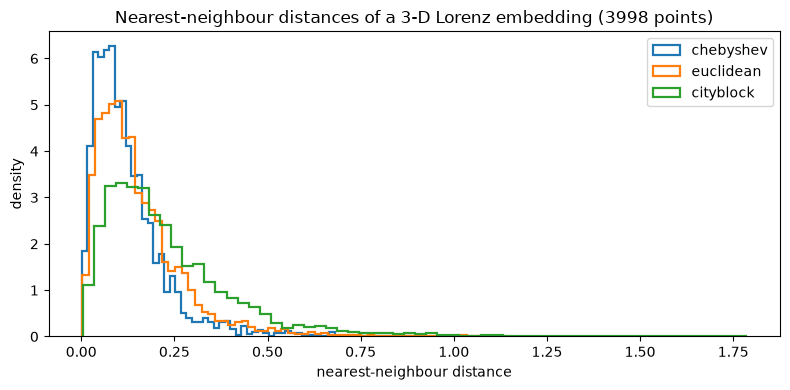

In [11]:
from scipy.spatial import cKDTree

from nolitisea.core.embed import delay_embedding

_, states = lorenz(length=4000)
ts = states[:, 0]
emb = delay_embedding(ts, dim=3, delay=1)

fig, ax = plt.subplots(figsize=(8, 4))
for p, metric in [(np.inf, "chebyshev"), (2.0, "euclidean"), (1.0, "cityblock")]:
    tree = cKDTree(emb)
    knn_dist, index = tree.query(emb, k=2, p=p)   # column 0 is the point itself
    neighbours = emb[index[:, 1]]

    d = pairwise_row_distance(emb, neighbours, metric=metric)
    np.testing.assert_allclose(d, knn_dist[:, 1])  # agrees with the tree
    ax.hist(d, bins=60, density=True, histtype="step", lw=1.6, label=metric)

ax.set_xlabel("nearest-neighbour distance")
ax.set_ylabel("density")
ax.set_title(f"Nearest-neighbour distances of a 3-D Lorenz embedding "
             f"({emb.shape[0]} points)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. `parallel_map` — order-preserving parallel map

`nolitisea.utils.parallel.parallel_map(func, items, n_jobs=None,
backend="thread")` applies `func` to every item and returns the results in
input order — a parallel analogue of `[func(item) for item in items]`.

- `n_jobs` — `None` or `1` runs serially with zero executor overhead;
  `-1` uses all CPUs; a positive integer caps the worker count.
- `backend="thread"` — thread pool, ideal for NumPy/SciPy kernels
  that release the GIL: no pickling, low overhead, no spawn cost.
- `backend="process"` — process pool for pure-Python work; the function
  must be picklable (a top-level/imported function, not a lambda or a
  notebook-defined closure), and Windows pays process-spawn costs.

Results are always returned in the original item order and exceptions
raised in workers propagate to the caller.

In [12]:
from nolitisea.utils.parallel import parallel_map

def square(x):
    return x * x

items = list(range(10))

serial = parallel_map(square, items)             # n_jobs=None: plain loop
threads = parallel_map(square, items, n_jobs=4)  # thread pool

print("items  :", items)
print("serial :", serial)
print("threads:", threads)
print("order preserved and results equal:", threads == serial)

items  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
serial : [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
threads: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
order preserved and results equal: True


### Threads speed up GIL-releasing kernels

The vectorised NumPy kernels in `pairwise_row_distance` release the GIL
inside their C loops, so a thread pool scales across CPU cores.
  Each task is independent and deterministic, hence the parallel and
  serial results are bitwise identical.

In [13]:
import os
import time

from nolitisea.utils.dist import pairwise_row_distance

def mean_pair_distance(seed):
    rng = np.random.default_rng(seed)
    a = rng.standard_normal((100_000, 6))
    b = rng.standard_normal((100_000, 6))
    return pairwise_row_distance(a, b, metric="euclidean").mean()

chunks = list(range(8))

mean_pair_distance(0)  # warm-up call before timing

t0 = time.perf_counter()
serial_res = parallel_map(mean_pair_distance, chunks)
t_serial = time.perf_counter() - t0

t0 = time.perf_counter()
thread_res = parallel_map(mean_pair_distance, chunks, n_jobs=-1,
                          backend="thread")
t_thread = time.perf_counter() - t0

print(f"CPUs available: {os.cpu_count()}")
print(f"serial  : {t_serial:.2f} s")
print(f"threads : {t_thread:.2f} s  (speedup {t_serial / t_thread:.2f}x)")
print(f"bitwise-identical results: {thread_res == serial_res}")

CPUs available: 16
serial  : 0.09 s
threads : 0.02 s  (speedup 5.05x)
bitwise-identical results: True


### Process backend and error propagation

The process pool is meant for pure-Python work that holds the GIL.  On
Windows (spawn) the worker and its arguments must be picklable, so an
imported function such as `math.factorial` works while lambdas and
notebook-defined closures do not.  Exceptions raised inside workers
propagate to the caller under both backends.

In [14]:
import math

t0 = time.perf_counter()
factorials = parallel_map(math.factorial, range(600, 608),
                          n_jobs=4, backend="process")
t_process = time.perf_counter() - t0
print(f"600! has {len(str(factorials[0]))} digits")
print(f"process pool finished in {t_process:.2f} s "
      f"(spawn overhead dominates for tiny tasks)")

# Worker exceptions propagate to the caller.
def boom(x):
    raise ValueError(f"bad item: {x}")

try:
    parallel_map(boom, [1, 2, 3], n_jobs=2)
except ValueError as err:
    print(f"propagated worker error: {err}")

600! has 1409 digits
process pool finished in 0.41 s (spawn overhead dominates for tiny tasks)
propagated worker error: bad item: 1


## Summary

The `nolitisea.utils` package collects the preprocessing and execution
primitives shared by the analysis routines:

- **`rescale_data(x)`** — affine Min-Max scaling to `[0, 1]`; returns the
  scaled series together with `(minv, interval)` for the exact inverse
  transform, and raises `RuntimeError` for a constant series.
- **`resample(series, sampletime, order)`** — local polynomial
  interpolation at a new sampling interval; `< 1` up-samples, `> 1`
  down-samples, and higher `order` gives smoother fits.
- **`pairwise_row_distance(x, y, metric)`** — row-by-row distances
  (`chebyshev`, `euclidean`, `cityblock`) via vectorised NumPy; the
  distance primitive behind neighbour-based embedding analysis.
- **`parallel_map(func, items, n_jobs, backend)`** — order-preserving
  parallel map; use `thread` for GIL-releasing kernels (NumPy/SciPy)
  and `process` for pure-Python work with picklable top-level functions.